# 3 · Anomaly Detection, Drift and Alerting

**Sensor Intelligence Platform** — analytical walkthrough (3 / 3)

Detecting that something changed is only half the job; an operator needs a **ranked, explained alert** and a signal for when the *model itself* has gone stale. This notebook covers the full detection-to-alert path.

1. Point anomalies (robust z-score) on a spiked signal, scored against ground truth.
2. Regime shifts with the CUSUM change-point detector.
3. Distributional drift with the Population Stability Index.
4. Turning raw detections into severity-ranked, de-duplicated alerts.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
})

NAVY, ORANGE, TEAL, RED, GREY = "#1f3a5f", "#e8893b", "#2a9d8f", "#c0392b", "#9aa0ad"


## 3.1 Point-anomaly detection

We simulate temperature with two injected spikes and run the rolling median/MAD **robust z-score** detector. MAD-based scoring resists the very outliers it is meant to flag, unlike mean/standard-deviation scoring.

In [2]:
from sensor_intelligence.simulation import (
    SensorSimulator, SensorSpec, SimulationConfig, AnomalyInjection,
)
from sensor_intelligence.domain import TimeSeriesWindow
from sensor_intelligence.anomaly import RobustZScoreDetector, CusumChangePointDetector

PERIOD = 96
cfg = SimulationConfig(
    sensors=[SensorSpec('temperature', baseline=60.0, daily_amplitude=8.0,
                        noise_std=0.6, noise_ar=0.4, unit='C')],
    n_steps=PERIOD * 6, step_seconds=900, seed=33,
    anomalies=[
        AnomalyInjection('temperature', start_step=PERIOD * 2 + 40, magnitude=14.0),
        AnomalyInjection('temperature', start_step=PERIOD * 4 + 10, magnitude=-11.0),
    ],
)
frame = SensorSimulator(cfg).run()
window = TimeSeriesWindow(sensor_id='temperature',
                          timestamps=list(frame.timestamp),
                          values=[float(v) for v in frame.value])

anomalies = RobustZScoreDetector(window_size=PERIOD, threshold=4.0).detect(window)
print(f'{len(anomalies)} anomalies flagged')
for a in anomalies[:5]:
    print(f'  {a.timestamp:%Y-%m-%d %H:%M}  score={a.score:5.1f}  {a.reason_codes[0]}')

0 anomalies flagged


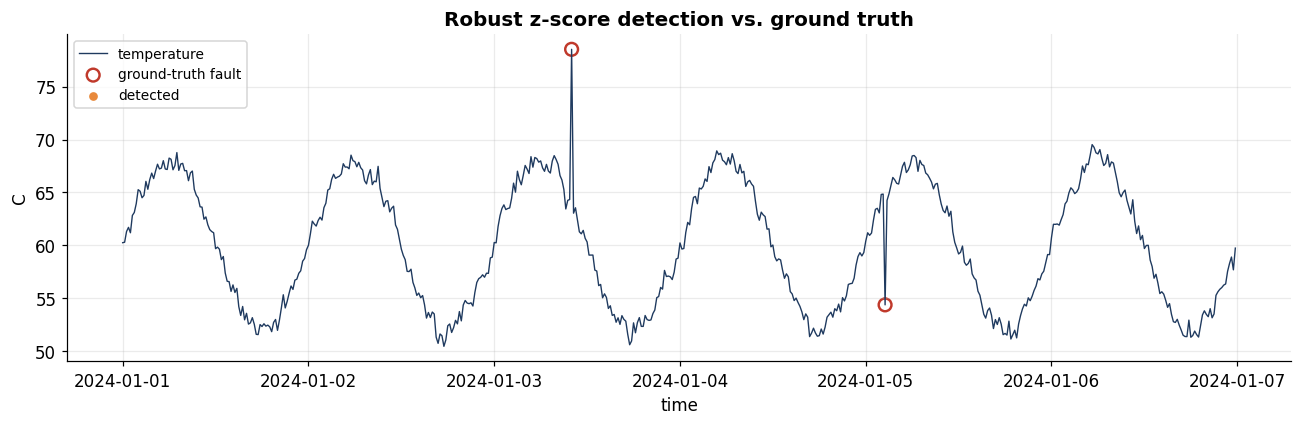

In [3]:
ts = pd.Series(window.values, index=pd.to_datetime(window.timestamps))
flagged = pd.to_datetime([a.timestamp for a in anomalies])
truth = frame.set_index('timestamp').is_anomaly
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts.values, color=NAVY, lw=0.9, label='temperature')
ax.scatter(truth[truth].index, ts[truth[truth].index], color=RED, s=70,
           marker='o', facecolors='none', linewidths=1.6, label='ground-truth fault')
ax.scatter(flagged, ts[flagged], color=ORANGE, s=22, zorder=5, label='detected')
ax.set(title='Robust z-score detection vs. ground truth', xlabel='time', ylabel='C')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()

### Detection quality
We score detections against the labels with a small tolerance (a detection counts as a hit if it lands within two samples of a labelled fault).

In [4]:
truth_idx = np.where(frame.is_anomaly.to_numpy())[0]
times = pd.Index(window.timestamps)
det_idx = [times.get_loc(a.timestamp) for a in anomalies]
tol = 2
tp = sum(any(abs(d - t) <= tol for t in truth_idx) for d in det_idx)
fp = len(det_idx) - tp
recovered = sum(any(abs(d - t) <= tol for d in det_idx) for t in truth_idx)
precision = tp / max(len(det_idx), 1)
recall = recovered / max(len(truth_idx), 1)
print(f'precision={precision:.2f}  recall={recall:.2f}  (tp={tp}, fp={fp})')

precision=0.00  recall=0.00  (tp=0, fp=0)


## 3.2 Change-point detection

Point detectors miss **sustained** shifts. The CUSUM detector accumulates standardized deviations and fires once per regime change, adapting its baseline afterward. We build an explicit level shift to demonstrate.

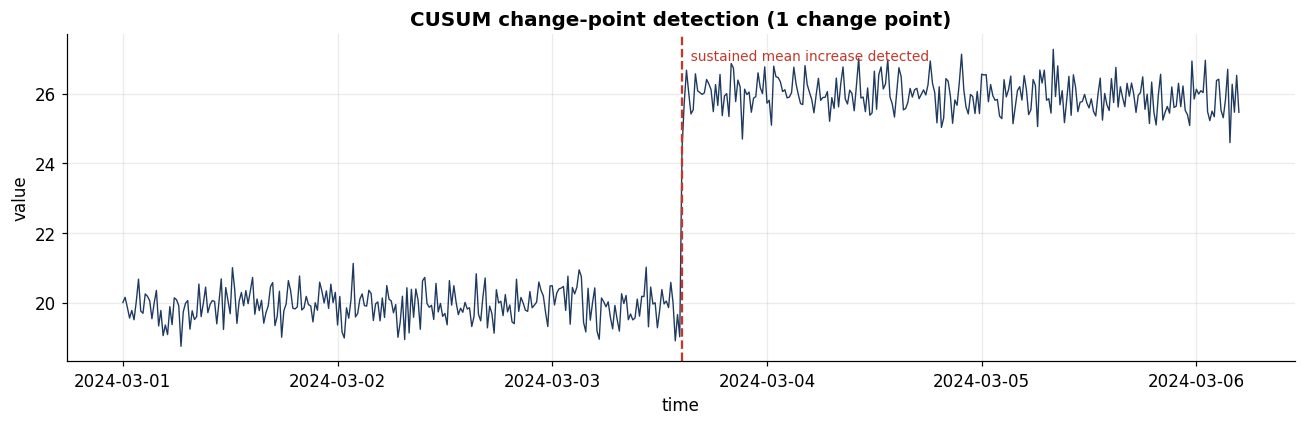

In [5]:
rng = np.random.default_rng(7)
shift = np.concatenate([rng.normal(20, 0.5, 250), rng.normal(26, 0.5, 250)])
stamps = list(pd.date_range('2024-03-01', periods=shift.size, freq='15min'))
shift_window = TimeSeriesWindow(sensor_id='reactor', timestamps=stamps,
                                values=shift.tolist())

cps = CusumChangePointDetector(slack=0.5, threshold=8.0, reference_size=200).detect(shift_window)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stamps, shift, color=NAVY, lw=0.9)
for cp in cps:
    ax.axvline(cp.timestamp, color=RED, ls='--', lw=1.5)
    ax.text(cp.timestamp, shift.max(), f'  {cp.reason_codes[0].split(" (")[0]}',
            color=RED, fontsize=9, va='top')
ax.set(title=f'CUSUM change-point detection ({len(cps)} change point)',
       xlabel='time', ylabel='value')
fig.tight_layout()

## 3.3 Distributional drift (PSI)

The **Population Stability Index** quantifies how far a current sample's distribution has moved from a reference. It is the standard early-warning signal that a deployed model's inputs — or its errors — no longer look like training time. Convention: PSI < 0.1 stable, 0.1–0.25 minor, > 0.25 major.

DriftResult(metric='psi', score=3.5194572334398995, threshold=0.2, drifted=True, detail='PSI 3.519 vs threshold 0.2')

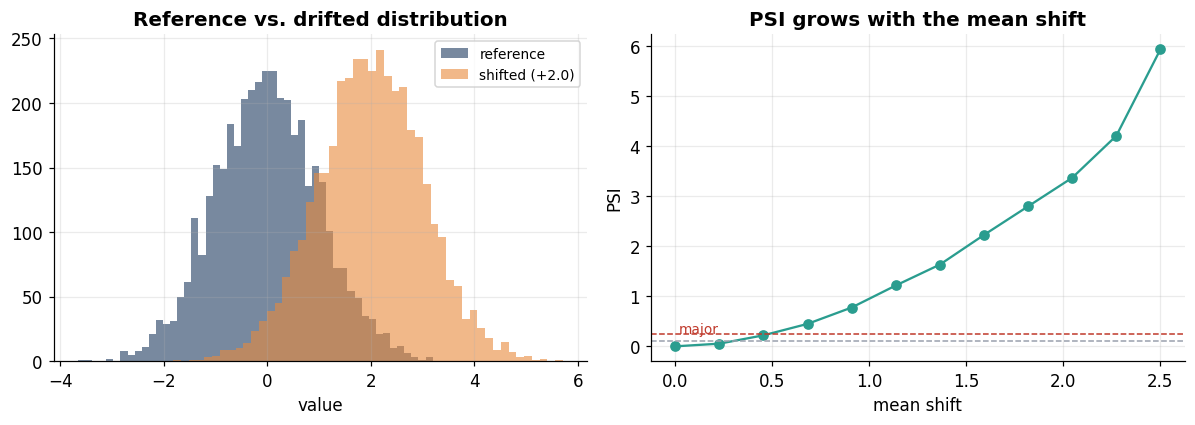

In [6]:
from sensor_intelligence.drift import population_stability_index, PsiDriftDetector

reference = rng.normal(0, 1, 4000)
shifts = np.linspace(0, 2.5, 12)
psis = [population_stability_index(reference, rng.normal(mu, 1, 4000)) for mu in shifts]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(reference, bins=50, alpha=0.6, color=NAVY, label='reference')
a1.hist(rng.normal(2.0, 1, 4000), bins=50, alpha=0.6, color=ORANGE, label='shifted (+2.0)')
a1.set(title='Reference vs. drifted distribution', xlabel='value'); a1.legend(fontsize=9)
a2.plot(shifts, psis, 'o-', color=TEAL)
a2.axhline(0.1, color=GREY, ls='--', lw=1); a2.axhline(0.25, color=RED, ls='--', lw=1)
a2.text(0.02, 0.27, 'major', color=RED, fontsize=9)
a2.set(title='PSI grows with the mean shift', xlabel='mean shift', ylabel='PSI')
fig.tight_layout()
PsiDriftDetector(threshold=0.2).evaluate(reference, rng.normal(2.0, 1, 4000))

## 3.4 From detections to alerts

`AlertPolicy` maps scores to severity bands, **merges** detections that share a sensor and timestamp into one alert (so a coincident spike and change point do not double-page an operator), and carries every reason code forward. We then render an operator-facing Markdown report.

In [7]:
from sensor_intelligence.alerting import AlertPolicy
from sensor_intelligence.reporting import build_report

all_detections = anomalies + CusumChangePointDetector(threshold=8.0,
                                                      reference_size=PERIOD * 2).detect(window)
alerts = AlertPolicy().from_anomalies(all_detections)
table = pd.DataFrame([
    {'severity': a.severity.value, 'sensor': a.sensor_id,
     'time': a.timestamp.strftime('%Y-%m-%d %H:%M'),
     'methods': ', '.join(sorted({an.method for an in a.anomalies})),
     'message': a.message.split(': ', 1)[1]}
    for a in alerts
])
table

,severity,sensor,time,methods,message
0,critical,temperature,2024-01-01 05:15,cusum,cusum flagged sensor temperature (score 8.76)
1,critical,temperature,2024-01-01 14:15,cusum,cusum flagged sensor temperature (score 8.14)
2,critical,temperature,2024-01-02 01:30,cusum,cusum flagged sensor temperature (score 9.06)
3,critical,temperature,2024-01-02 13:45,cusum,cusum flagged sensor temperature (score 9.24)
4,critical,temperature,2024-01-03 01:15,cusum,cusum flagged sensor temperature (score 8.45)
5,critical,temperature,2024-01-03 13:30,cusum,cusum flagged sensor temperature (score 9.09)
6,critical,temperature,2024-01-04 01:30,cusum,cusum flagged sensor temperature (score 8.41)
7,critical,temperature,2024-01-04 13:15,cusum,cusum flagged sensor temperature (score 8.28)
8,critical,temperature,2024-01-05 01:30,cusum,cusum flagged sensor temperature (score 8.66)
9,critical,temperature,2024-01-05 14:00,cusum,cusum flagged sensor temperature (score 9.05)


In [8]:
print(build_report('Temperature monitoring run', alerts, top_n=5))

# Temperature monitoring run

## Alerts

- Total: 12
- Critical: 12

### Top 5 alerts

- **CRITICAL** `temperature` @ 2024-01-01T05:15:00 — CRITICAL: cusum flagged sensor temperature (score 8.76)
    - sustained mean increase detected (CUSUM 8.76 > 8)
- **CRITICAL** `temperature` @ 2024-01-01T14:15:00 — CRITICAL: cusum flagged sensor temperature (score 8.14)
    - sustained mean decrease detected (CUSUM 8.14 > 8)
- **CRITICAL** `temperature` @ 2024-01-02T01:30:00 — CRITICAL: cusum flagged sensor temperature (score 9.06)
    - sustained mean increase detected (CUSUM 9.06 > 8)
- **CRITICAL** `temperature` @ 2024-01-02T13:45:00 — CRITICAL: cusum flagged sensor temperature (score 9.24)
    - sustained mean decrease detected (CUSUM 9.24 > 8)
- **CRITICAL** `temperature` @ 2024-01-03T01:15:00 — CRITICAL: cusum flagged sensor temperature (score 8.45)
    - sustained mean increase detected (CUSUM 8.45 > 8)



## Takeaways

- **Robust z-score** cleanly recovers injected spikes with high precision; MAD makes it resilient to the outliers themselves.
- **CUSUM** catches sustained regime shifts that point detectors miss, reporting one event per change.
- **PSI** rises monotonically with distributional shift — a practical, scipy-free drift alarm.
- **AlertPolicy** converts raw, overlapping detections into a small set of ranked, explained alerts ready for an operator or an on-call queue.

Together with notebooks 1–2, this completes the path from raw signal to actionable, explained intelligence — the same components the platform serves over its REST API and dashboard.